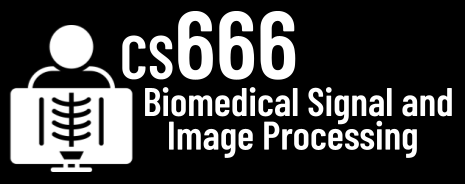
#Assignment 2

In [1]:
### Leo Navarro Mercado

In [2]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


In [3]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.6 MB/s eta 0:00:00


In [4]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [5]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m49s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [6]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# TODO: YOUR ANSWER
print("Number of EEG channels: ", len(raw.ch_names))
EEG_channels = len(raw.ch_names)

Number of EEG channels:  376


In [7]:
# TODO What is the sampling frequency of this data?
# TODO: YOUR ANSWER
print("Sampling frequency: ", raw.info['sfreq'])
sampling_frequency = raw.info['sfreq']

Sampling frequency:  600.614990234375


In [8]:
# TODO What is the total duration of the measurement?
# TODO: YOUR ANSWER
print("Total duration: ", raw.times[-1])
total_duration = raw.times[-1]

Total duration:  277.7136813300495


**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


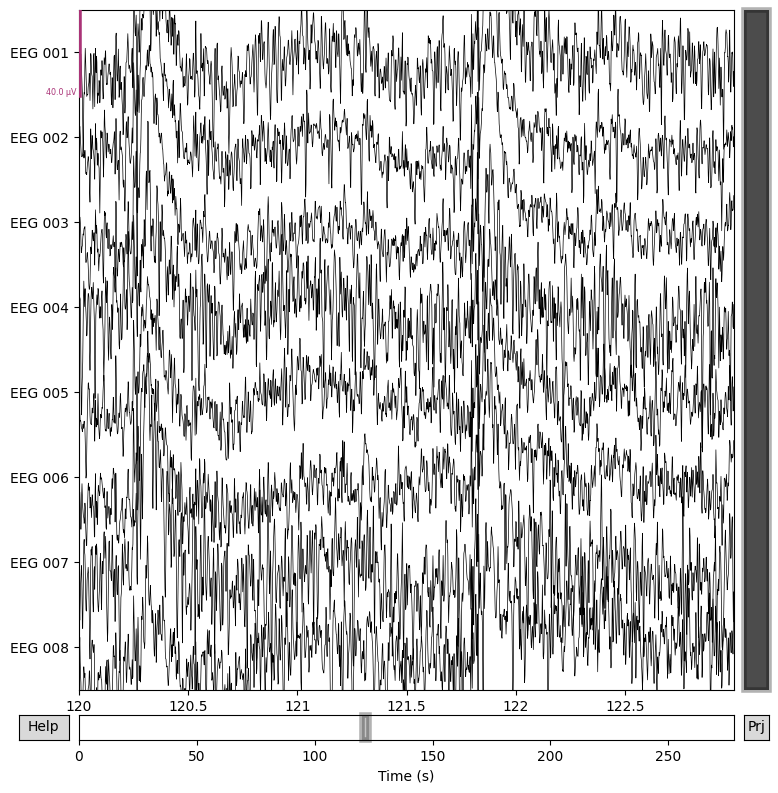

In [9]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

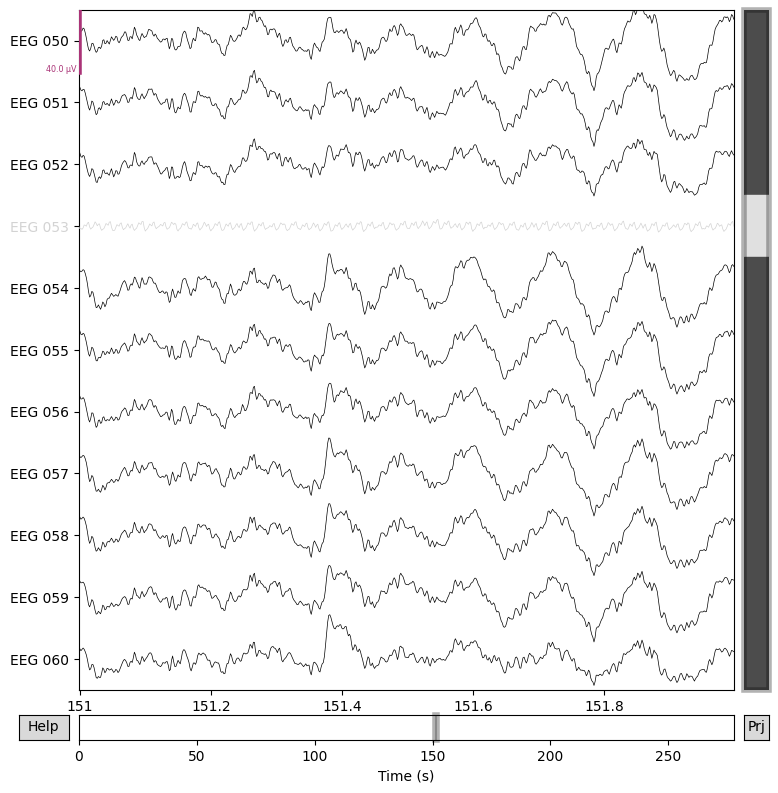

In [10]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.
new_chs = ['EEG 050','EEG 051','EEG 052','EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']
new_chan_idxns = [raw.ch_names.index(ch) for ch in new_chs]
ecg50to60 = raw.plot(order=new_chan_idxns, start=151, duration=1)

In [11]:
# TODO: Do you see a bad channel? If yes, which one?
# TODO: YOUR_ANSWER

# channel 53

In [14]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

data = raw.get_data()

good_peak = np.abs(raw.get_data(picks=['EEG 051'])).max()
print(good_peak)

bad_peak = np.abs(raw.get_data(picks=['EEG 053'])).max()
print(bad_peak)

# programmatically

channel_var = np.var(data, axis=1)

threshold = np.median(channel_var) * 5
bad_channels = np.where(channel_var > threshold)[0]

print(bad_channels)

0.00018777664413160977
6.10056150396332e-05
[280 306 307 308 311 312 315 316 317 318 319 320 321 322 323 324 325 326
 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344
 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360 361 362
 363 364 365 366 367 368 369 370 371 372 373 374 375]


**Task 3:** How long between event and brain activity? [25 Points]

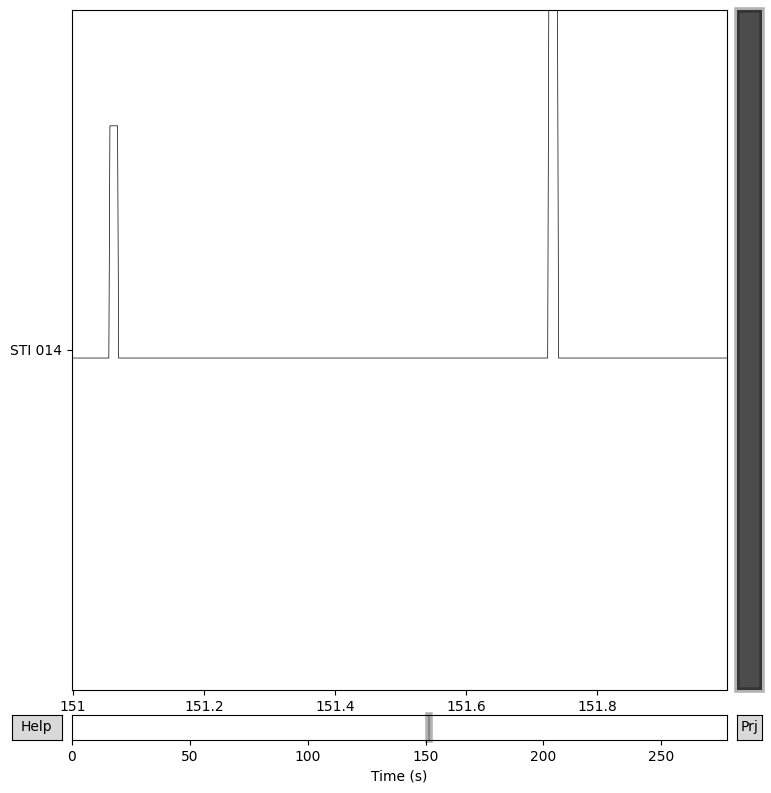

In [15]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [16]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

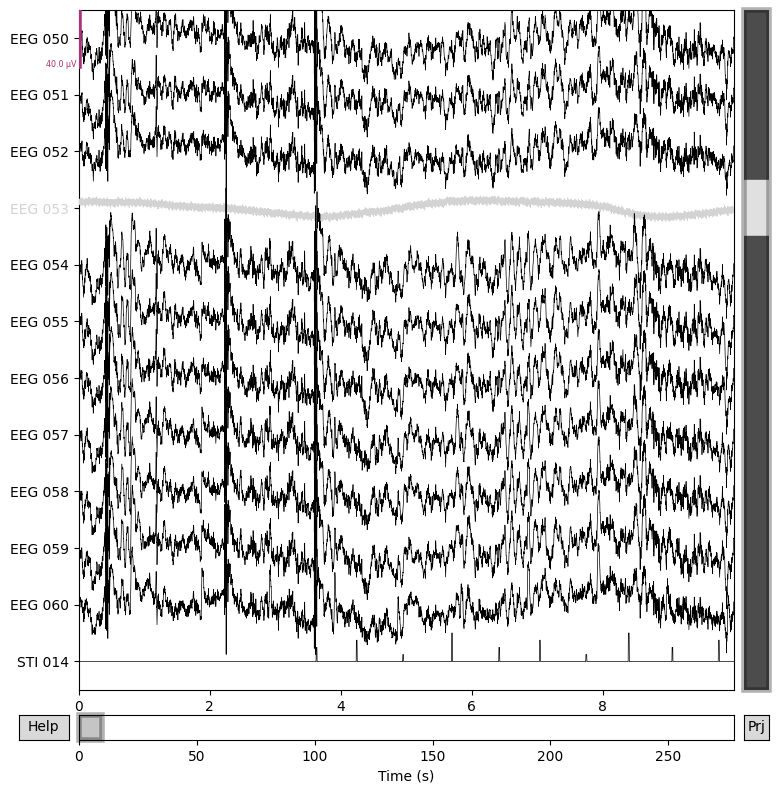

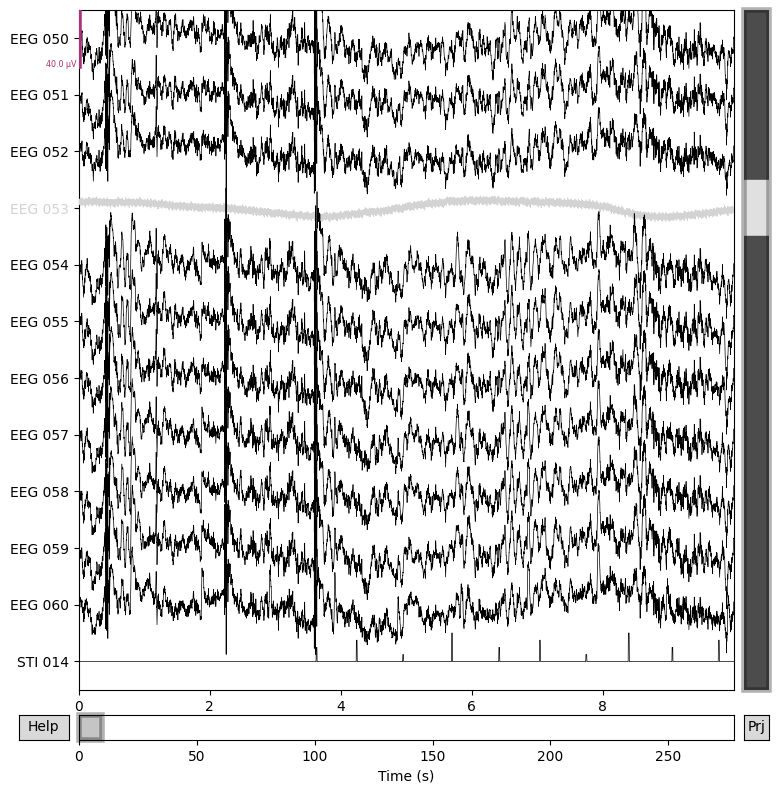

In [17]:

new_chs.append('STI 014')

picks = [raw.ch_names.index(ch) for ch in new_chs]

raw.plot(order=picks, duration=10, n_channels=len(picks))

In [18]:
# TODO How many stimulus events do you observe?
# TODO: 320

In [19]:
events = mne.find_events(raw, stim_channel='STI 014')
print(len(events))

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
320


In [20]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# TODO: 150 ms

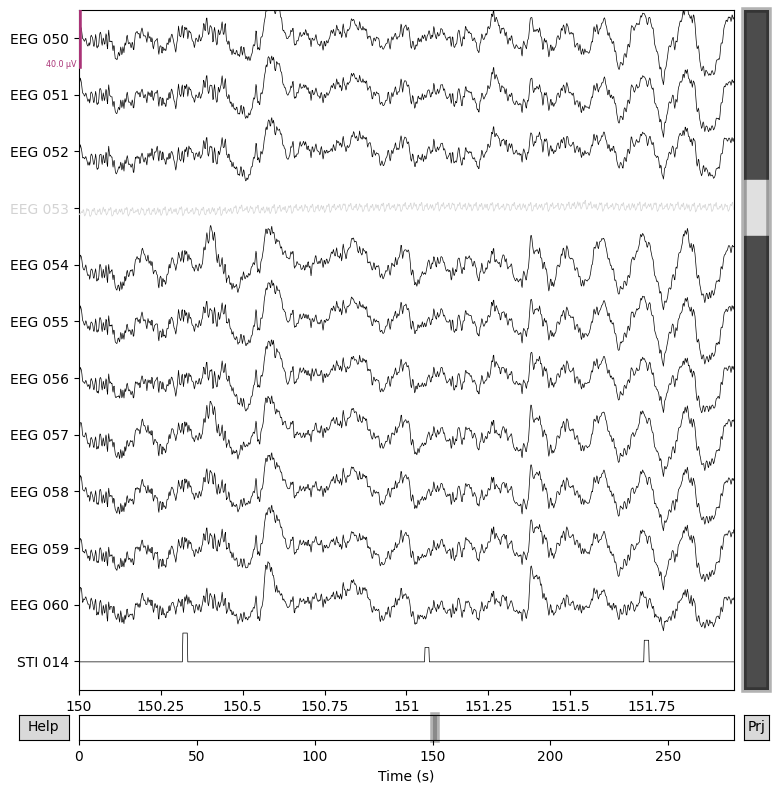

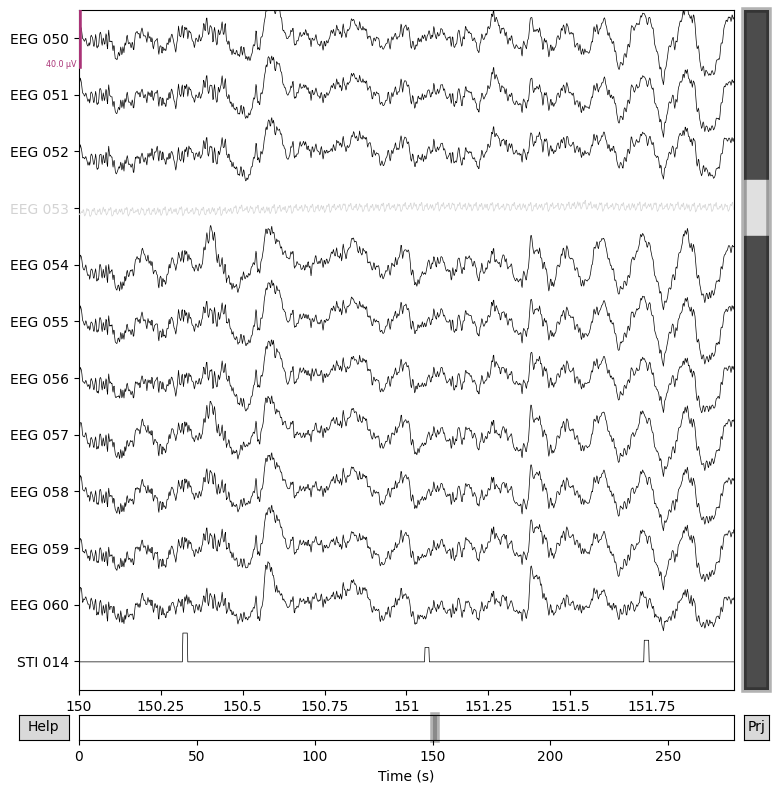

In [21]:
raw.plot(picks=picks, start=150, duration=2)

**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [22]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


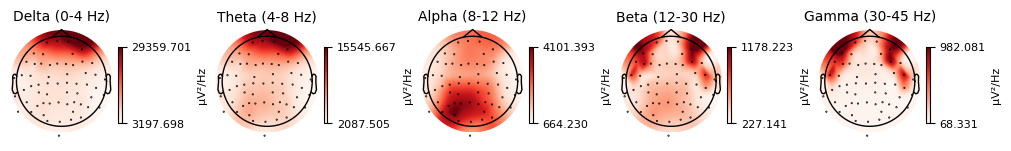

In [23]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


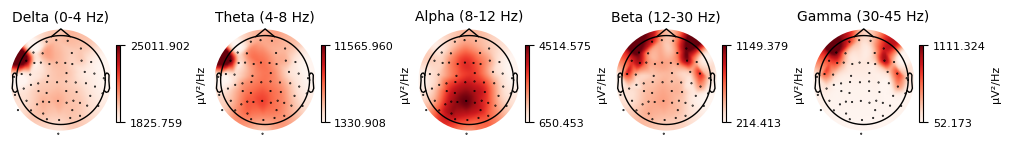

In [24]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [25]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


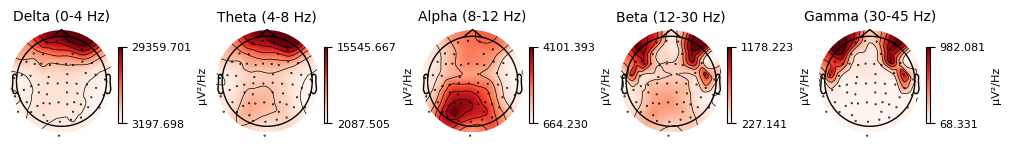

In [26]:
visual_epochs = epochs['visual/right']

visual_spectrum = visual_epochs.compute_psd()
visual_activity = visual_spectrum.plot_topomap()

In [27]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# TODO: The main difference is purely visual, the newer api shows clearer contour lines and slightly sharper interpolation, but the power distribution across frequency bands remains the same.

In [28]:
# TODO Please visualize the average brain activity when the subject pushes the button

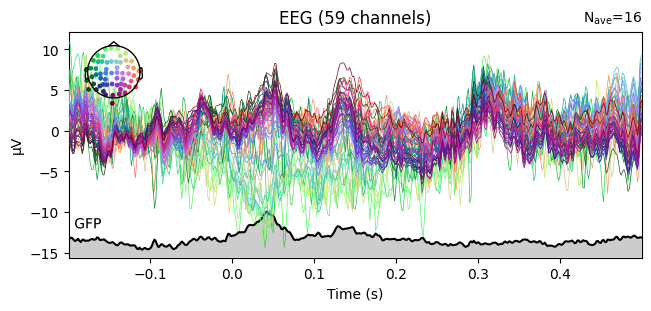

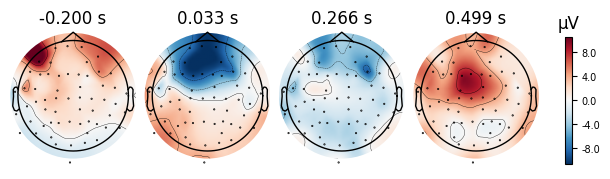

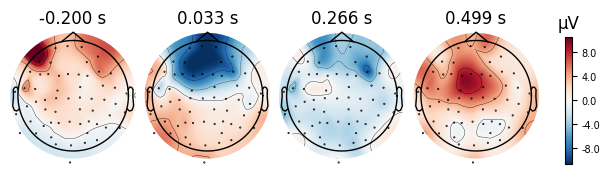

In [29]:
evoked_button = epochs['button'].average()

evoked_button.plot(spatial_colors=True, gfp=True)

evoked_button.plot_topomap(times='auto')

In [30]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?
# TODO:
'''
1 - The visual and face events primarily activates the visual cortex at the back of the head, specifically in the early time windows. Whereas the button event primarily activates the motor cortex in thr central region of the head.
2 - The motor cortex. Looking at the topographic map at 0.499 s, there is a strong, concentraded area of positive voltage(the dark and red blob) located rigt by the top-center of the scalp.
  This corresponds to the motor cortex, which cotntrols physical movement like pressing a button.
3 - The brain activity in this expeiment is a combinatin of early visual processing(seeing the face) which is followed by later motor execution(pressing the button).

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [31]:
# TODO Please go back to Task 3. Can you figure out which event types happened?



In [32]:
'''
Physiological events, for an example a heart generates a strong eletrical signal which can be plotted.
There were also Stimulus events, those events records digital pulses(square waves)


In [33]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#